Generating dataset...
Dataset saved: manhole_model_output\dataset.csv
label
normal      2000
flood       1200
blockage     800
Name: count, dtype: int64
Training model...
CV Score: 1.0

Classification Report:
              precision    recall  f1-score   support

    blockage       1.00      1.00      1.00       160
       flood       1.00      1.00      1.00       240
      normal       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

Model saved!


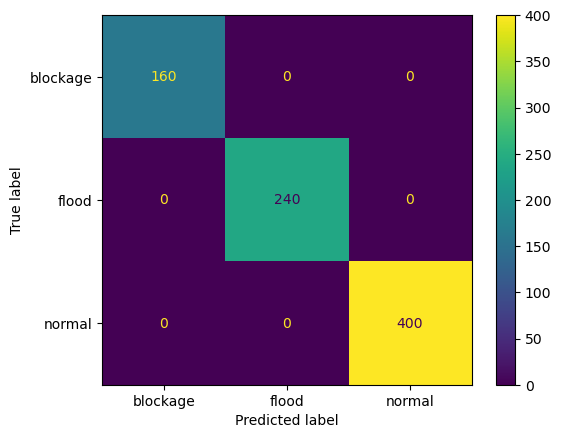


Demo Predictions:
['normal' 'flood' 'blockage']


In [1]:
# ─────────────────────────────────────────────
# IMPORTS (FIXED)
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_NORMAL = 2000
N_FLOOD = 1200
N_BLOCKAGE = 800

OUTPUT_DIR = "manhole_model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# DATA GENERATION (cm scale)
# ─────────────────────────────────────────────

def generate_normal(n):
    return pd.DataFrame({
        "water_level_node1": np.random.uniform(1, 15, n),
        "water_level_node2": np.random.uniform(1, 15, n),
        "rise_rate_node1": np.random.uniform(0.0, 2.0, n),
        "rise_rate_node2": np.random.uniform(0.0, 2.0, n),
        "rain_hour": np.random.choice([0, 1, 2], n, p=[0.6, 0.3, 0.1]),
        "rain_intensity": np.random.uniform(0.0, 5.0, n),
        "label": "normal",
    })


def generate_flood(n):
    half = n // 2

    a = pd.DataFrame({
        "water_level_node1": np.random.uniform(16, 30, half),
        "water_level_node2": np.random.uniform(16, 30, half),
        "rise_rate_node1": np.random.uniform(4, 12, half),
        "rise_rate_node2": np.random.uniform(3, 10, half),
        "rain_hour": np.random.choice([0, 1], half),
        "rain_intensity": np.random.uniform(20.0, 60.0, half),
        "label": "flood",
    })

    b = pd.DataFrame({
        "water_level_node1": np.random.uniform(25, 35, n - half),
        "water_level_node2": np.random.uniform(25, 35, n - half),
        "rise_rate_node1": np.random.uniform(5, 15, n - half),
        "rise_rate_node2": np.random.uniform(4, 12, n - half),
        "rain_hour": np.random.choice([1, 2, 3], n - half),
        "rain_intensity": np.random.uniform(30.0, 80.0, n - half),
        "label": "flood",
    })

    return pd.concat([a, b], ignore_index=True)


def generate_blockage(n):
    return pd.DataFrame({
        "water_level_node1": np.random.uniform(20, 35, n),
        "water_level_node2": np.random.uniform(1, 10, n),
        "rise_rate_node1": np.random.uniform(6, 20, n),
        "rise_rate_node2": np.random.uniform(-1, 1, n),
        "rain_hour": np.random.choice([0, 1, 2, 3], n),
        "rain_intensity": np.random.uniform(0.0, 30.0, n),
        "label": "blockage",
    })


# ─────────────────────────────────────────────
# CREATE DATASET
# ─────────────────────────────────────────────

print("Generating dataset...")

df = pd.concat([
    generate_normal(N_NORMAL),
    generate_flood(N_FLOOD),
    generate_blockage(N_BLOCKAGE)
], ignore_index=True)

# level difference
df["level_diff"] = df["water_level_node1"] - df["water_level_node2"]

# realistic noise for cm
numeric_cols = [c for c in df.columns if c != "label"]
for col in numeric_cols:
    df[col] += np.random.normal(0, 0.5, len(df))  # FIXED

# shuffle
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# save dataset
csv_path = os.path.join(OUTPUT_DIR, "dataset.csv")
df.to_csv(csv_path, index=False)

print("Dataset saved:", csv_path)
print(df["label"].value_counts())


# ─────────────────────────────────────────────
# MODEL TRAINING
# ─────────────────────────────────────────────

FEATURES = [
    "water_level_node1",
    "water_level_node2",
    "level_diff",
    "rise_rate_node1",
    "rise_rate_node2",
    "rain_hour",
    "rain_intensity",
]

le = LabelEncoder()
X = df[FEATURES].values
y = le.fit_transform(df["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print("Training model...")

rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# cross validation
cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="f1_weighted")
print("CV Score:", cv.mean())

# predictions
y_pred = rf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# ─────────────────────────────────────────────
# SAVE MODEL
# ─────────────────────────────────────────────

joblib.dump(rf, os.path.join(OUTPUT_DIR, "model.joblib"))
joblib.dump(le, os.path.join(OUTPUT_DIR, "encoder.joblib"))

print("Model saved!")


# ─────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot()
plt.show()


# ─────────────────────────────────────────────
# DEMO (FIXED TO CM)
# ─────────────────────────────────────────────

print("\nDemo Predictions:")

demo = pd.DataFrame([
    [2, 5, 2 - 5, 0.5, 0.4, 0, 1.0],     # normal
    [30, 28, 30 - 28, 10, 8, 1, 50.0],   # flood
    [30, 5, 30 - 5, 15, 0, 0, 5.0],      # blockage
], columns=FEATURES)

pred = rf.predict(demo.values)
print(le.inverse_transform(pred))